In [31]:
# WSI-only binary pipeline for predicting class_labels_MYC_V2_median
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import mutual_info_score

# Paths and target config
data_path = Path("/app/data/yash-m2m/Data/full_data_table.csv")
wsi_feature_dir = Path("/app/data/yash-m2m/Data/Features/WSI Features")

target_col = "class_labels_MYC_V2_median"
wsi_exam_col = "chosen_exam"
allowed_labels = ["below_median", "above_median"]
random_state = 123

## 1) Build WSI-only dataset
Load the clinical table, map each sample to its WSI embedding, and keep only rows with valid embeddings and labels.

In [32]:
df = pd.read_csv(data_path, index_col=0)

required_cols = [target_col, wsi_exam_col]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Missing required columns in full_data_table.csv: {missing_required}")

unexpected_labels = set(df[target_col].dropna().astype(str).unique()) - set(allowed_labels)
if unexpected_labels:
    raise ValueError(f"Unexpected values in {target_col}: {sorted(unexpected_labels)}")

def load_wsi_embedding(npz_name: str):
    npz_path = wsi_feature_dir / str(npz_name)
    if not npz_path.exists():
        return None
    with np.load(npz_path) as data:
        return np.ravel(data["arr_0"]).astype(float)

wsi_df = df[[target_col, wsi_exam_col]].copy()
wsi_df["wsi_embedding"] = wsi_df[wsi_exam_col].apply(load_wsi_embedding)

In [33]:
n_missing_embeddings = int(wsi_df["wsi_embedding"].isna().sum())
wsi_df = wsi_df.dropna(subset=[target_col, "wsi_embedding"]).copy()

embedding_lengths = wsi_df["wsi_embedding"].apply(len)
if embedding_lengths.nunique() != 1:
    raise ValueError(
        f"WSI embedding lengths are inconsistent: {embedding_lengths.value_counts().to_dict()}"
    )

wsi_feature_df = pd.DataFrame(
    wsi_df["wsi_embedding"].tolist(),
    index=wsi_df.index,
    columns=[f"wsi_{i:04d}" for i in range(int(embedding_lengths.iloc[0]))],
)

X_wsi = wsi_feature_df.apply(pd.to_numeric, errors="coerce")
y_wsi = wsi_df[target_col].astype(str)
class_order = allowed_labels.copy()

print("Loaded rows with valid WSI:", len(X_wsi))
print("Missing WSI embeddings:", n_missing_embeddings)
print("WSI feature dimension:", X_wsi.shape[1])
print("\nClass distribution:")
print(y_wsi.value_counts(dropna=False))

X_wsi.head()

Loaded rows with valid WSI: 323
Missing WSI embeddings: 0
WSI feature dimension: 1024

Class distribution:
class_labels_MYC_V2_median
above_median    164
below_median    159
Name: count, dtype: int64


,wsi_0000,wsi_0001,wsi_0002,wsi_0003,wsi_0004,wsi_0005,wsi_0006,wsi_0007,wsi_0008,wsi_0009,...,wsi_1014,wsi_1015,wsi_1016,wsi_1017,wsi_1018,wsi_1019,wsi_1020,wsi_1021,wsi_1022,wsi_1023
TCGA-A3-3311,0.094205,0.007828,0.013351,0.020291,0.013857,0.003229,0.072589,0.050152,0.065535,0.016127,...,0.033546,0.010505,0.030839,0.004469,0.000782,0.031042,0.039687,0.005163,0.017557,0.047203
TCGA-A3-3316,0.082407,0.007476,0.011442,0.025793,0.014859,0.002722,0.062528,0.054409,0.056407,0.020648,...,0.023399,0.010450,0.025932,0.007075,0.000864,0.020411,0.042243,0.009459,0.023266,0.065137
TCGA-A3-3317,0.080404,0.016842,0.007083,0.034550,0.014582,0.002194,0.079892,0.059431,0.079821,0.020173,...,0.065695,0.006913,0.020288,0.006504,0.000585,0.028285,0.047470,0.008491,0.017466,0.082171
TCGA-A3-3320,0.091176,0.007396,0.010124,0.033648,0.015745,0.002486,0.093777,0.055947,0.063832,0.014052,...,0.015950,0.013336,0.020499,0.017306,0.001141,0.020963,0.049558,0.006282,0.030056,0.041318
TCGA-A3-3322,0.079067,0.011373,0.006703,0.027626,0.012603,0.001318,0.090948,0.057711,0.060303,0.016628,...,0.057463,0.008065,0.029229,0.005487,0.000812,0.029687,0.039037,0.006389,0.010945,0.051071


## 2) Helper functions
Reusable helpers for binary AUC, CV evaluation, and mRMR-MID feature ranking.

In [34]:
def binary_auc(y_true, y_prob):
    y_true = pd.Series(y_true).astype(str)
    y_bin = (y_true == "above_median").astype(int)  # assuming above_median is positive
    return roc_auc_score(y_bin, y_prob)

def evaluate_models_cv_binary(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = 123,
    n_splits: int = 10,
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    cv_logit_acc, cv_logit_f1, cv_logit_auc = [], [], []
    cv_rf_acc, cv_rf_f1, cv_rf_auc = [], [], []
    all_logit_probs, all_logit_obs = [], []
    all_rf_probs, all_rf_obs = [], []

    for tr_idx, va_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        logit = LogisticRegression(
            C=1e10,
            max_iter=3000,
            random_state=random_state,
        )
        logit.fit(X_tr, y_tr)
        logit_pred = logit.predict(X_val)
        logit_prob = logit.predict_proba(X_val)[:, 1]  # prob of positive class

        cv_logit_acc.append(accuracy_score(y_val, logit_pred))
        cv_logit_f1.append(f1_score(y_val, logit_pred, average="macro", zero_division=0))
        cv_logit_auc.append(binary_auc(y_val, logit_prob))
        all_logit_probs.extend(logit_prob.tolist())
        all_logit_obs.extend(y_val.tolist())

        n_feats = X_tr.shape[1]
        rf = RandomForestClassifier(
            n_estimators=500,
            max_features=max(1, math.floor(math.sqrt(n_feats))),
            random_state=random_state,
        )
        rf.fit(X_tr, y_tr)
        rf_pred = rf.predict(X_val)
        rf_prob = rf.predict_proba(X_val)[:, 1]

        cv_rf_acc.append(accuracy_score(y_val, rf_pred))
        cv_rf_f1.append(f1_score(y_val, rf_pred, average="macro", zero_division=0))
        cv_rf_auc.append(binary_auc(y_val, rf_prob))
        all_rf_probs.extend(rf_prob.tolist())
        all_rf_obs.extend(y_val.tolist())

    return {
        "cv_logit_acc": float(np.mean(cv_logit_acc)),
        "cv_logit_f1": float(np.mean(cv_logit_f1)),
        "cv_logit_auc": float(np.mean(cv_logit_auc)),
        "cv_rf_acc": float(np.mean(cv_rf_acc)),
        "cv_rf_f1": float(np.mean(cv_rf_f1)),
        "cv_rf_auc": float(np.mean(cv_rf_auc)),
        "all_logit_obs": all_logit_obs,
        "all_logit_probs": all_logit_probs,
        "all_rf_obs": all_rf_obs,
        "all_rf_probs": all_rf_probs,
    }

def evaluate_models_test_binary(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    random_state: int = 123,
):
    logit = LogisticRegression(
        C=1e10,
        max_iter=3000,
        random_state=random_state,
    )
    logit.fit(X_train, y_train)
    logit_pred = logit.predict(X_test)
    logit_prob = logit.predict_proba(X_test)[:, 1]

    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(X_train.shape[1]))),
        random_state=random_state,
    )
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_prob = rf.predict_proba(X_test)[:, 1]

    return {
        "test_logit_acc": accuracy_score(y_test, logit_pred),
        "test_logit_f1": f1_score(y_test, logit_pred, average="macro", zero_division=0),
        "test_logit_auc": binary_auc(y_test, logit_prob),
        "test_rf_acc": accuracy_score(y_test, rf_pred),
        "test_rf_f1": f1_score(y_test, rf_pred, average="macro", zero_division=0),
        "test_rf_auc": binary_auc(y_test, rf_prob),
        "test_logit_prob": logit_prob,
        "test_rf_prob": rf_prob,
    }

def _discretize_series(s: pd.Series, n_bins: int = 5) -> pd.Series:
    s = s.copy()
    if pd.api.types.is_numeric_dtype(s):
        non_na = s.dropna()
        if non_na.nunique() <= 2:
            return s.fillna(non_na.median() if len(non_na) else 0).astype(float).round().astype(int)
        try:
            binned = pd.qcut(non_na, q=min(n_bins, non_na.nunique()), labels=False, duplicates="drop")
            out = pd.Series(index=s.index, dtype=float)
            out.loc[non_na.index] = binned.astype(float)
            out = out.fillna(out.median() if out.notna().any() else 0)
            return out.astype(int)
        except Exception:
            return pd.factorize(s.fillna("__MISSING__").astype(str))[0]
    return pd.factorize(s.fillna("__MISSING__").astype(str))[0]

def run_python_mrmr_mid_binary(
    X_train_df: pd.DataFrame,
    y_train_series: pd.Series,
    n_features: int = 200,
    class_order: list = None,
):
    if class_order is None:
        class_order = sorted(y_train_series.astype(str).unique().tolist())

    y_num = pd.Categorical(y_train_series.astype(str), categories=class_order).codes
    X_disc = pd.DataFrame({c: _discretize_series(X_train_df[c]) for c in X_train_df.columns}, index=X_train_df.index)

    relevance = pd.Series(
        {c: mutual_info_score(X_disc[c].astype(int), y_num.astype(int)) for c in X_disc.columns}
    )

    cols = list(X_disc.columns)
    redundancy = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, ci in enumerate(cols):
        xi = X_disc[ci].astype(int)
        for j in range(i + 1, len(cols)):
            cj = cols[j]
            xj = X_disc[cj].astype(int)
            mi_ij = mutual_info_score(xi, xj)
            redundancy.loc[ci, cj] = mi_ij
            redundancy.loc[cj, ci] = mi_ij

    selected = []
    remaining = cols.copy()

    first = relevance.sort_values(ascending=False).index[0]
    selected.append(first)
    remaining.remove(first)

    while len(selected) < min(n_features, len(cols)) and remaining:
        scores = {}
        for c in remaining:
            red = redundancy.loc[c, selected].mean() if selected else 0.0
            scores[c] = relevance[c] - red

        score_series = pd.Series(scores)
        best_score = score_series.max()
        tied = score_series[score_series == best_score].index.tolist()
        if len(tied) > 1:
            tied = sorted(tied, key=lambda k: (-relevance[k], k))
        best = tied[0]

        selected.append(best)
        remaining.remove(best)

    return selected

## 3) Baseline with all WSI features
Train Logistic and Random Forest on all available WSI dimensions (expected 1024).

In [35]:
X_train_wsi, X_test_wsi, y_train_wsi, y_test_wsi = train_test_split(
    X_wsi,
    y_wsi,
    test_size=0.2,
    stratify=y_wsi,
    random_state=random_state,
 )

all_wsi_cv = evaluate_models_cv_binary(
    X_train=X_train_wsi,
    y_train=y_train_wsi,
    random_state=random_state,
    n_splits=10,
 )

all_wsi_test = evaluate_models_test_binary(
    X_train=X_train_wsi,
    y_train=y_train_wsi,
    X_test=X_test_wsi,
    y_test=y_test_wsi,
    random_state=random_state,
 )

all_wsi_summary = pd.Series({
    "n_samples": len(X_wsi),
    "n_features": X_wsi.shape[1],
    "cv_logit_acc": all_wsi_cv["cv_logit_acc"],
    "cv_logit_macro_f1": all_wsi_cv["cv_logit_f1"],
    "cv_logit_auc": all_wsi_cv["cv_logit_auc"],
    "cv_rf_acc": all_wsi_cv["cv_rf_acc"],
    "cv_rf_macro_f1": all_wsi_cv["cv_rf_f1"],
    "cv_rf_auc": all_wsi_cv["cv_rf_auc"],
    "test_logit_acc": all_wsi_test["test_logit_acc"],
    "test_logit_macro_f1": all_wsi_test["test_logit_f1"],
    "test_logit_auc": all_wsi_test["test_logit_auc"],
    "test_rf_acc": all_wsi_test["test_rf_acc"],
    "test_rf_macro_f1": all_wsi_test["test_rf_f1"],
    "test_rf_auc": all_wsi_test["test_rf_auc"],
})

print("All-WSI baseline results:")
all_wsi_summary

All-WSI baseline results:


n_samples               323.000000
n_features             1024.000000
cv_logit_acc              0.538769
cv_logit_macro_f1         0.535904
cv_logit_auc              0.487541
cv_rf_acc                 0.561692
cv_rf_macro_f1            0.558436
cv_rf_auc                 0.447288
test_logit_acc            0.430769
test_logit_macro_f1       0.430769
test_logit_auc            0.499527
test_rf_acc               0.507692
test_rf_macro_f1          0.504762
test_rf_auc               0.532670
dtype: float64

## 4) Feature selection on WSI only (mRMR-MID)
Use the same leakage-safe strategy as before: rank features on an outer training split only.

In [7]:
# Outer split for leakage-safe feature selection + holdout evaluation
X_outer_train, X_outer_test, y_outer_train, y_outer_test = train_test_split(
    X_wsi,
    y_wsi,
    test_size=0.2,
    stratify=y_wsi,
    random_state=random_state,
 )

# Practical default for runtime; raise toward 200 if you want a wider search.
max_features_to_rank = min(120, X_outer_train.shape[1])

selected_wsi_features = run_python_mrmr_mid_binary(
    X_train_df=X_outer_train,
    y_train_series=y_outer_train,
    n_features=max_features_to_rank,
    class_order=class_order,
)

print(f"Ranked WSI features: {len(selected_wsi_features)}")
print("Top 20 selected features:")
print(selected_wsi_features[:20])

Ranked WSI features: 120
Top 20 selected features:
['wsi_0920', 'wsi_0568', 'wsi_0461', 'wsi_0953', 'wsi_0635', 'wsi_0492', 'wsi_0041', 'wsi_0172', 'wsi_0182', 'wsi_0481', 'wsi_0015', 'wsi_0917', 'wsi_0127', 'wsi_0656', 'wsi_0939', 'wsi_0761', 'wsi_0833', 'wsi_0702', 'wsi_0079', 'wsi_0021']


## 5) Top-k scan over selected WSI features
Evaluate Logistic and RF across increasing k to find the best compact WSI-only model.

In [ ]:
results = []

# Dense early grid + coarser tail for speed/stability with high-dimensional WSI
k_grid = list(range(1, min(30, len(selected_wsi_features)) + 1))
k_grid += [k for k in [40, 50, 60, 75, 100, 125, 150, 175, 200] if k <= len(selected_wsi_features)]
k_grid = sorted(set(k_grid))

for k in k_grid:
    features_k = selected_wsi_features[:k]
    X_train_k = X_outer_train[features_k]

    cv_res_k = evaluate_models_cv_binary(
        X_train=X_train_k,
        y_train=y_outer_train,
        random_state=random_state,
        n_splits=10,
    )

    results.append(
        {
            "k": k,
            "logit_f1": cv_res_k["cv_logit_f1"],
            "logit_auc": cv_res_k["cv_logit_auc"],
            "rf_f1": cv_res_k["cv_rf_f1"],
            "rf_auc": cv_res_k["cv_rf_auc"],
        }
    )

results_df = pd.DataFrame(results).sort_values("k").reset_index(drop=True)

best_logit_f1_idx = results_df["logit_f1"].idxmax()
best_logit_auc_idx = results_df["logit_auc"].idxmax()
best_rf_f1_idx = results_df["rf_f1"].idxmax()
best_rf_auc_idx = results_df["rf_auc"].idxmax()

k_best_logit_f1 = int(results_df.loc[best_logit_f1_idx, "k"])
k_best_logit_auc = int(results_df.loc[best_logit_auc_idx, "k"])
k_best_rf_f1 = int(results_df.loc[best_rf_f1_idx, "k"])
k_best_rf_auc = int(results_df.loc[best_rf_auc_idx, "k"])

best_summary = pd.DataFrame(
    {
        "model": ["Logistic", "Logistic", "RF", "RF"],
        "metric": ["Macro-F1", "AUC", "Macro-F1", "AUC"],
        "best_k": [k_best_logit_f1, k_best_logit_auc, k_best_rf_f1, k_best_rf_auc],
        "best_value": [
            results_df.loc[best_logit_f1_idx, "logit_f1"],
            results_df.loc[best_logit_auc_idx, "logit_auc"],
            results_df.loc[best_rf_f1_idx, "rf_f1"],
            results_df.loc[best_rf_auc_idx, "rf_auc"],
        ],
    }
)

print("Best CV values by model/metric:")
display(best_summary)

KeyboardInterrupt: 

## 6) Evaluate best-k model(s) on holdout test
Use the outer holdout split to report final metrics for k chosen by CV.

In [ ]:
def evaluate_on_holdout_binary(features):
    X_tr = X_outer_train[features]
    X_te = X_outer_test[features]

    test_res = evaluate_models_test_binary(
        X_train=X_tr,
        y_train=y_outer_train,
        X_test=X_te,
        y_test=y_outer_test,
        random_state=random_state,
    )
    return test_res

print("Holdout test metrics at best-k values:")
for label, k_val in [
    ("Logistic Macro-F1", k_best_logit_f1),
    ("Logistic AUC", k_best_logit_auc),
    ("RF Macro-F1", k_best_rf_f1),
    ("RF AUC", k_best_rf_auc),
]:
    feats = selected_wsi_features[:k_val]
    res = evaluate_on_holdout_binary(feats)
    print(
        f"  k={k_val:3d} ({label}): "
        f"Logit ACC={res['test_logit_acc']:.3f} F1={res['test_logit_f1']:.3f} AUC={res['test_logit_auc']:.3f} | "
        f"RF ACC={res['test_rf_acc']:.3f} F1={res['test_rf_f1']:.3f} AUC={res['test_rf_auc']:.3f}"
    )

# Single best-k choice for plotting/comparison (highest CV Macro-F1 across both models)
logit_best_f1 = results_df.loc[best_logit_f1_idx, "logit_f1"]
rf_best_f1 = results_df.loc[best_rf_f1_idx, "rf_f1"]
if logit_best_f1 >= rf_best_f1:
    best_k_final = k_best_logit_f1
    best_k_source = f"Logistic Macro-F1 (k={k_best_logit_f1}, F1={logit_best_f1:.3f})"
else:
    best_k_final = k_best_rf_f1
    best_k_source = f"RF Macro-F1 (k={k_best_rf_f1}, F1={rf_best_f1:.3f})"

print(f"\nChosen best-k for WSI-only final view: k={best_k_final} [{best_k_source}]")

best_k_features = selected_wsi_features[:best_k_final]
best_k_cv = evaluate_models_cv_binary(
    X_train=X_outer_train[best_k_features],
    y_train=y_outer_train,
    random_state=random_state,
    n_splits=10,
)
best_k_test = evaluate_models_test_binary(
    X_train=X_outer_train[best_k_features],
    y_train=y_outer_train,
    X_test=X_outer_test[best_k_features],
    y_test=y_outer_test,
    random_state=random_state,
)

best_k_summary = pd.Series({
    "best_k": best_k_final,
    "best_k_source": best_k_source,
    "cv_logit_macro_f1": best_k_cv["cv_logit_f1"],
    "cv_logit_auc": best_k_cv["cv_logit_auc"],
    "cv_rf_macro_f1": best_k_cv["cv_rf_f1"],
    "cv_rf_auc": best_k_cv["cv_rf_auc"],
    "test_logit_macro_f1": best_k_test["test_logit_f1"],
    "test_logit_auc": best_k_test["test_logit_auc"],
    "test_rf_macro_f1": best_k_test["test_rf_f1"],
    "test_rf_auc": best_k_test["test_rf_auc"],
})

print("\nBest-k WSI-only summary:")
best_k_summary

Holdout test metrics at best-k values:
  k= 50 (Logistic Macro-F1): Logit ACC=0.462 F1=0.459 AUC=0.491 | RF ACC=0.508 F1=0.493 AUC=0.536
  k=  3 (Logistic AUC): Logit ACC=0.462 F1=0.462 AUC=0.491 | RF ACC=0.492 F1=0.490 AUC=0.523
  k= 28 (RF Macro-F1): Logit ACC=0.492 F1=0.492 AUC=0.483 | RF ACC=0.569 F1=0.561 AUC=0.445
  k=  1 (RF AUC): Logit ACC=0.538 F1=0.537 AUC=0.469 | RF ACC=0.538 F1=0.537 AUC=0.451

Chosen best-k for WSI-only final view: k=28 [RF Macro-F1 (k=28, F1=0.610)]

Best-k WSI-only summary:


best_k                                           28
best_k_source          RF Macro-F1 (k=28, F1=0.610)
cv_logit_macro_f1                          0.480421
cv_logit_auc                                0.45671
cv_rf_macro_f1                             0.610251
cv_rf_auc                                  0.362623
test_logit_macro_f1                        0.492308
test_logit_auc                             0.482955
test_rf_macro_f1                           0.560811
test_rf_auc                                0.444602
dtype: object

## 7) Visualize top-k trend and ROC
Plot CV performance vs. k and ROC curves for the chosen best-k models.

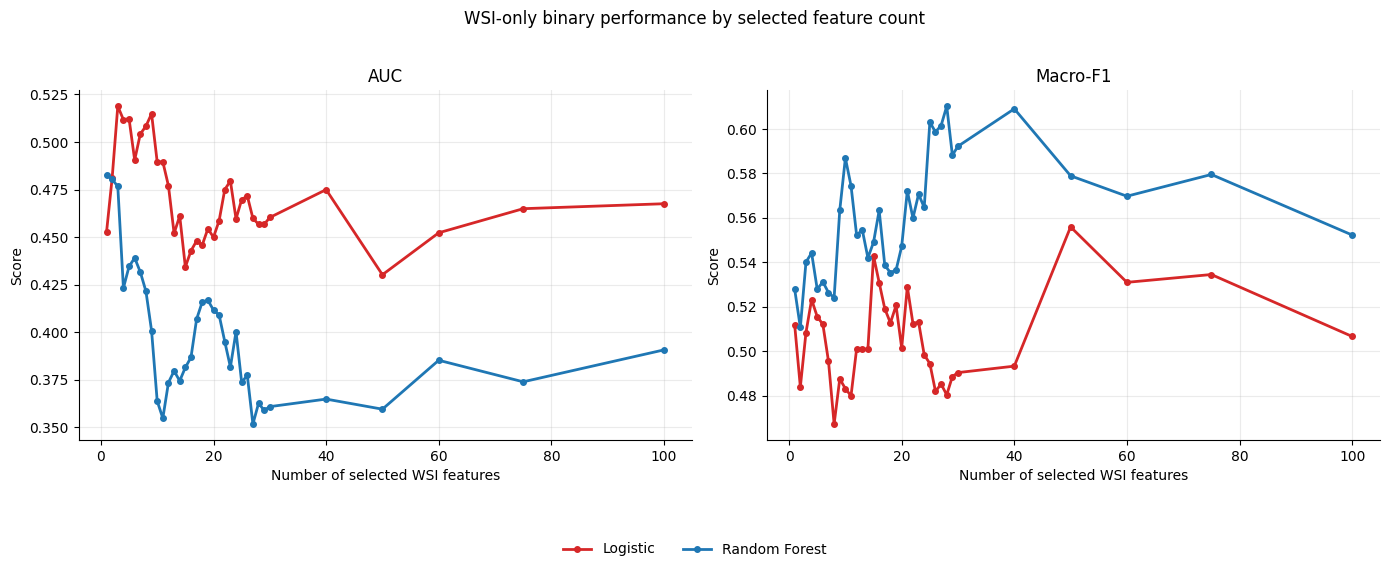

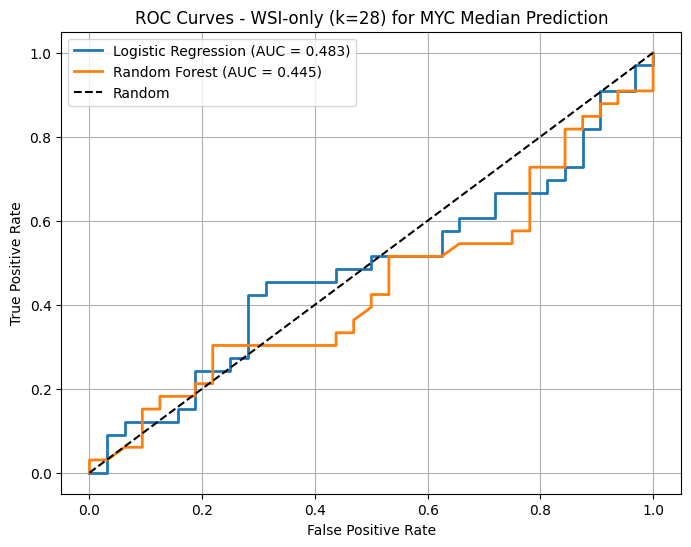

In [ ]:
# Performance curves across k
results_long = results_df.melt(
    id_vars=["k"],
    value_vars=["logit_f1", "logit_auc", "rf_f1", "rf_auc"],
    var_name="metric_model",
    value_name="score",
)
results_long[["model", "metric"]] = results_long["metric_model"].str.split("_", expand=True)
results_long["model"] = results_long["model"].map({"logit": "Logistic", "rf": "Random Forest"})
results_long["metric"] = results_long["metric"].map({"f1": "Macro-F1", "auc": "AUC"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Logistic": "#d62728", "Random Forest": "#1f77b4"}

for ax, metric in zip(axes, ["AUC", "Macro-F1"]):
    subset = results_long[results_long["metric"] == metric]
    for model in ["Logistic", "Random Forest"]:
        m = subset[subset["model"] == model]
        ax.plot(
            m["k"],
            m["score"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=model,
            color=colors[model],
        )
    ax.set_xlabel("Number of selected WSI features")
    ax.set_ylabel("Score")
    ax.set_title(metric)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25)

fig.legend(["Logistic", "Random Forest"], loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
fig.suptitle("WSI-only binary performance by selected feature count", y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.16)
plt.show()

# ROC curves on outer holdout using best-k
best_feats = selected_wsi_features[:best_k_final]
X_train_best = X_outer_train[best_feats]
X_test_best = X_outer_test[best_feats]

logit_best = LogisticRegression(
    C=1e10,
    max_iter=3000,
    random_state=random_state,
)
logit_best.fit(X_train_best, y_outer_train)
logit_test_prob = logit_best.predict_proba(X_test_best)[:, 1]

rf_best = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(best_feats)))),
    random_state=random_state,
)
rf_best.fit(X_train_best, y_outer_train)
rf_test_prob = rf_best.predict_proba(X_test_best)[:, 1]

y_bin_test = (pd.Series(y_outer_test) == "above_median").astype(int)

fpr_logit, tpr_logit, _ = roc_curve(y_bin_test, logit_test_prob)
auc_logit = roc_auc_score(y_bin_test, logit_test_prob)

fpr_rf, tpr_rf, _ = roc_curve(y_bin_test, rf_test_prob)
auc_rf = roc_auc_score(y_bin_test, rf_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logit, tpr_logit, label=f'Logistic Regression (AUC = {auc_logit:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curves - WSI-only (k={best_k_final}) for MYC Median Prediction')
plt.legend()
plt.grid(True)
plt.show()

## 9) Combined WSI + Genomics Final Model
Create final Random Forest and Logistic Regression models using top 28 WSI features + selected genomics features.

In [ ]:
# Top 28 WSI features + genomics features
wsi_features_28 = selected_wsi_features[:28]

genomics_features = [
    "TMB_Count",
    "Func_MEGF6",
    "Func_ATG7",
    "Func_POLDIP2",
    "Func_COL5A3",
    "Func_MSLNL",
    "Func_SERPINB13",
    "Func_ST8SIA4",
    "Func_OR2T35",
    "Func_CHIT1",
    "Func_CASP5",
    "Func_TAS2R50",
    "Func_HOXC8",
    "Func_ARHGAP5",
    "Func_ANKRD36",
    "Func_SYT15",
    "Func_FAM209A",
    "Func_VCX3B",
    "Func_PTPRK",
    "Func_GATA2",
    "Func_CACYBP",
]

print(f"WSI features (k=28): {len(wsi_features_28)}")
print(f"Genomics features: {len(genomics_features)}")

# Extract genomics features from the original dataframe, aligned with outer split indices
X_genomics_train = df.loc[X_outer_train.index, genomics_features].apply(pd.to_numeric, errors="coerce")
X_genomics_test = df.loc[X_outer_test.index, genomics_features].apply(pd.to_numeric, errors="coerce")

# Combine features from both modalities
combined_features = wsi_features_28 + genomics_features
print(f"Total combined features: {len(combined_features)}")

# Prepare combined data using the outer split indices
X_train_combined = pd.concat([X_outer_train[wsi_features_28], X_genomics_train], axis=1)
X_test_combined = pd.concat([X_outer_test[wsi_features_28], X_genomics_test], axis=1)

print(f"\nX_train_combined shape: {X_train_combined.shape}")
print(f"X_test_combined shape: {X_test_combined.shape}")
print(f"y_outer_train shape: {y_outer_train.shape}")
print(f"y_outer_test shape: {y_outer_test.shape}")

WSI features (k=28): 28
Genomics features: 21
Total combined features: 49

X_train_combined shape: (258, 49)
X_test_combined shape: (65, 49)
y_outer_train shape: (258,)
y_outer_test shape: (65,)


In [ ]:
# Handle NaN values and ensure proper alignment
print("Checking for NaN values before model training:")
print(f"  X_train_combined NaNs: {X_train_combined.isna().sum().sum()}")
print(f"  X_test_combined NaNs: {X_test_combined.isna().sum().sum()}")

# Fill NaN values with column medians
X_train_combined = X_train_combined.fillna(X_train_combined.median())
X_test_combined = X_test_combined.fillna(X_test_combined.median())

# Reset indices to ensure alignment with labels
X_train_combined = X_train_combined.reset_index(drop=True)
X_test_combined = X_test_combined.reset_index(drop=True)
y_outer_train_reset = pd.Series(y_outer_train.values, index=range(len(y_outer_train)))
y_outer_test_reset = pd.Series(y_outer_test.values, index=range(len(y_outer_test)))

print(f"\nAfter cleaning:")
print(f"  X_train_combined shape: {X_train_combined.shape}")
print(f"  X_test_combined shape: {X_test_combined.shape}")
print(f"  y_outer_train_reset shape: {y_outer_train_reset.shape}")
print(f"  y_outer_test_reset shape: {y_outer_test_reset.shape}")

# Train final Logistic Regression and Random Forest models
logit_final = LogisticRegression(
    C=1e10,
    max_iter=3000,
    random_state=random_state,
)
logit_final.fit(X_train_combined, y_outer_train_reset)
logit_train_pred = logit_final.predict(X_train_combined)
logit_test_pred = logit_final.predict(X_test_combined)
logit_train_prob = logit_final.predict_proba(X_train_combined)[:, 1]
logit_test_prob = logit_final.predict_proba(X_test_combined)[:, 1]

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(combined_features)))),
    random_state=random_state,
)
rf_final.fit(X_train_combined, y_outer_train_reset)
rf_train_pred = rf_final.predict(X_train_combined)
rf_test_pred = rf_final.predict(X_test_combined)
rf_train_prob = rf_final.predict_proba(X_train_combined)[:, 1]
rf_test_prob = rf_final.predict_proba(X_test_combined)[:, 1]

# Calculate metrics
y_bin_train = (pd.Series(y_outer_train_reset) == "above_median").astype(int)
y_bin_test = (pd.Series(y_outer_test_reset) == "above_median").astype(int)

# Logistic Regression
logit_train_acc = accuracy_score(y_outer_train_reset, logit_train_pred)
logit_train_f1 = f1_score(y_outer_train_reset, logit_train_pred, average="macro", zero_division=0)
logit_train_auc = roc_auc_score(y_bin_train, logit_train_prob)

logit_test_acc = accuracy_score(y_outer_test_reset, logit_test_pred)
logit_test_f1 = f1_score(y_outer_test_reset, logit_test_pred, average="macro", zero_division=0)
logit_test_auc = roc_auc_score(y_bin_test, logit_test_prob)

# Random Forest
rf_train_acc = accuracy_score(y_outer_train_reset, rf_train_pred)
rf_train_f1 = f1_score(y_outer_train_reset, rf_train_pred, average="macro", zero_division=0)
rf_train_auc = roc_auc_score(y_bin_train, rf_train_prob)

rf_test_acc = accuracy_score(y_outer_test_reset, rf_test_pred)
rf_test_f1 = f1_score(y_outer_test_reset, rf_test_pred, average="macro", zero_division=0)
rf_test_auc = roc_auc_score(y_bin_test, rf_test_prob)

# Summary table
final_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Train_Accuracy": [logit_train_acc, rf_train_acc],
    "Train_F1": [logit_train_f1, rf_train_f1],
    "Train_AUC": [logit_train_auc, rf_train_auc],
    "Test_Accuracy": [logit_test_acc, rf_test_acc],
    "Test_F1": [logit_test_f1, rf_test_f1],
    "Test_AUC": [logit_test_auc, rf_test_auc],
})

print("\n" + "=" * 80)
print("FINAL COMBINED MODEL (WSI k=28 + Genomics) - Performance Summary")
print("=" * 80)
display(final_results)

Checking for NaN values before model training:
  X_train_combined NaNs: 5160
  X_test_combined NaNs: 1300

After cleaning:
  X_train_combined shape: (258, 49)
  X_test_combined shape: (65, 49)
  y_outer_train_reset shape: (258,)
  y_outer_test_reset shape: (65,)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

NameError: name 'logit_test_auc' is not defined

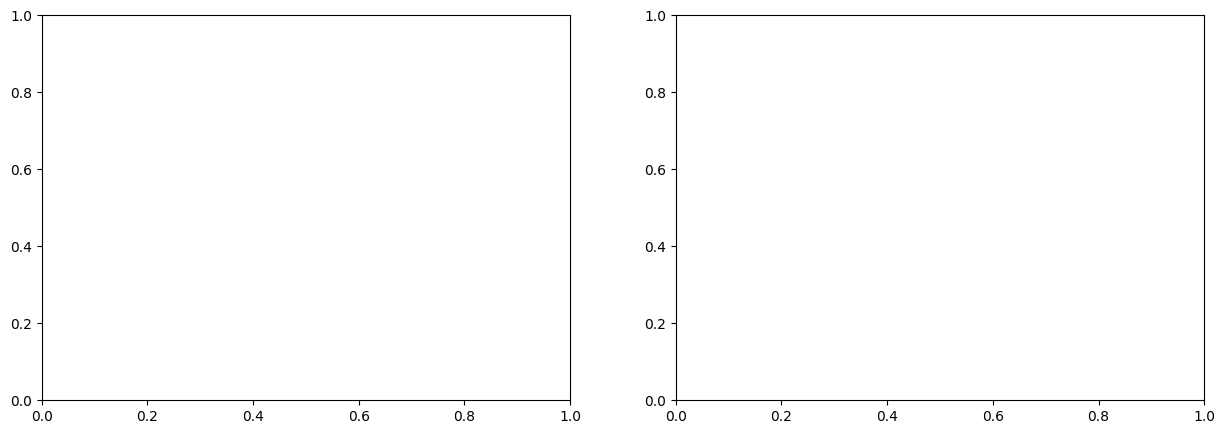

In [ ]:
# ROC Curves - Combined Model
fpr_logit, tpr_logit, _ = roc_curve(y_bin_test, logit_test_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_bin_test, rf_test_prob)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC curves
axes[0].plot(fpr_logit, tpr_logit, label=f'Logistic (AUC={logit_test_auc:.3f})', linewidth=2.5, color='#d62728')
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_test_auc:.3f})', linewidth=2.5, color='#1f77b4')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves - Test Set\n(WSI k=28 + Genomics)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([-0.02, 1.02])
axes[0].set_ylim([-0.02, 1.02])

# Performance comparison
models = ['Logistic', 'Random Forest']
x_pos = np.arange(len(models))
width = 0.25

acc_scores = [logit_test_acc, rf_test_acc]
f1_scores = [logit_test_f1, rf_test_f1]
auc_scores = [logit_test_auc, rf_test_auc]

axes[1].bar(x_pos - width, acc_scores, width, label='Accuracy', color='#2ca02c')
axes[1].bar(x_pos, f1_scores, width, label='F1-Score', color='#ff7f0e')
axes[1].bar(x_pos + width, auc_scores, width, label='AUC', color='#9467bd')

axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Test Performance - Combined Model\n(WSI k=28 + Genomics)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models)
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("DETAILED TEST SET METRICS")
print("=" * 80)
print("\nLogistic Regression:")
print(f"  Accuracy: {logit_test_acc:.3f}")
print(f"  F1-Score: {logit_test_f1:.3f}")
print(f"  AUC: {logit_test_auc:.3f}")

print("\nRandom Forest:")
print(f"  Accuracy: {rf_test_acc:.3f}")
print(f"  F1-Score: {rf_test_f1:.3f}")
print(f"  AUC: {rf_test_auc:.3f}")

In [ ]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': combined_features,
    'Importance': rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 20 features
top_features = feature_importance.head(20)

print("\n" + "=" * 80)
print("RANDOM FOREST - TOP 20 FEATURE IMPORTANCES")
print("=" * 80)
display(top_features)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors_feat = ['#1f77b4' if 'wsi_' in f else '#d62728' for f in top_features['Feature']]
ax.barh(range(len(top_features)), top_features['Importance'], color=colors_feat)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Random Forest - Top 20 Feature Importances\n(Blue=WSI, Red=Genomics)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary by feature type
wsi_importance = feature_importance[feature_importance['Feature'].str.startswith('wsi_')]['Importance'].sum()
genomics_importance = feature_importance[~feature_importance['Feature'].str.startswith('wsi_')]['Importance'].sum()

print("\n" + "=" * 80)
print("IMPORTANCE BY FEATURE TYPE")
print("=" * 80)
print(f"WSI Features (28): {wsi_importance:.4f} ({wsi_importance/( wsi_importance+genomics_importance)*100:.1f}%)")
print(f"Genomics Features (21): {genomics_importance:.4f} ({genomics_importance/(wsi_importance+genomics_importance)*100:.1f}%)")

NameError: name 'rf_final' is not defined

In [ ]:
# Final comprehensive summary
final_summary = pd.DataFrame({
    "Metric": ["Accuracy", "F1-Score", "AUC"],
    "Logistic_Train": [f"{logit_train_acc:.4f}", f"{logit_train_f1:.4f}", f"{logit_train_auc:.4f}"],
    "Logistic_Test": [f"{logit_test_acc:.4f}", f"{logit_test_f1:.4f}", f"{logit_test_auc:.4f}"],
    "RandomForest_Train": [f"{rf_train_acc:.4f}", f"{rf_train_f1:.4f}", f"{rf_train_auc:.4f}"],
    "RandomForest_Test": [f"{rf_test_acc:.4f}", f"{rf_test_f1:.4f}", f"{rf_test_auc:.4f}"],
})

print("\n" + "=" * 100)
print("FINAL SUMMARY - WSI (k=28) + GENOMICS (21 features) - CLASS_LABELS_MYC_V2_MEDIAN PREDICTION")
print("=" * 100)
print(f"\nTraining samples: {len(y_outer_train)}")
print(f"Test samples: {len(y_outer_test)}")
print(f"Total features: {len(combined_features)} (WSI: 28 + Genomics: 21)")
print("\n")
display(final_summary)

print("\n" + "=" * 100)
print("MODEL SELECTION RECOMMENDATION")
print("=" * 100)
if rf_test_auc > logit_test_auc:
    print(f"\n✓ RANDOM FOREST is the better model for this dataset")
    print(f"  Test AUC: {rf_test_auc:.4f} (vs Logistic: {logit_test_auc:.4f})")
    print(f"  Test Accuracy: {rf_test_acc:.4f} (vs Logistic: {logit_test_acc:.4f})")
else:
    print(f"\n✓ LOGISTIC REGRESSION is the better model for this dataset")
    print(f"  Test AUC: {logit_test_auc:.4f} (vs RF: {rf_test_auc:.4f})")
    print(f"  Test Accuracy: {logit_test_acc:.4f} (vs RF: {rf_test_acc:.4f})")

NameError: name 'logit_train_acc' is not defined